In [ ]:
!pip install scikit-learn pandas numpy seaborn matplotlib imbalanced-learn requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os

from imblearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel

In [ ]:
url = "https://data.mendeley.com/public-files/datasets/7m58kxs742/files/4d57de6a-a140-4607-bf38-146899f1a723/file_downloaded"
file_name = "Preprocessed_Balanced_dataset.csv"

print(f"Downloading {file_name}...")
response = requests.get(url)

if response.status_code == 200:
    with open(file_name, "wb") as f:
        f.write(response.content)
    print(f"{file_name} berhasil diunduh.\n")
else:
    print(f"Gagal mengunduh {file_name}. Status code: {response.status_code}\n")

df = pd.read_csv(file_name)
display(df.head())

Preprocessed_Balanced_dataset.csv berhasil diunduh.



,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category,Attack_sub_category
0,0.143546,1,42,1,1,4,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
1,0.000679,1,42,1,1,3,4,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
2,0.010981,1,42,1,1,11,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
3,0.000684,1,42,1,1,3,24,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning
4,0.012461,1,42,1,1,12,2,2,1,1,...,1,0,1,1,1,1,1,1,2,ARPPoisoning


In [ ]:
print("--- Dataset Info ---")
display(df.info())

print("\n--- Descriptive Statistics ---")
display(df.describe())

print("\n--- Missing Values ---")
missing_vals = df.isnull().sum()
display(missing_vals[missing_vals > 0] if not missing_vals.empty else "No missing values found.")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 88 columns):
 #   Column                                                      Non-Null Count    Dtype  
---  ------                                                      --------------    -----  
 0   dur                                                         1048575 non-null  float64
 1   Protocol                                                    1048575 non-null  int64  
 2   Length                                                      1048575 non-null  int64  
 3   Source Host                                                 1048575 non-null  int64  
 4   Destination Host                                            1048575 non-null  int64  
 5   Sender IP address                                           1048575 non-null  int64  
 6   Target IP address                                           1048575 non-null  int64  
 7   Opcode                                    

None


--- Descriptive Statistics ---


,dur,Protocol,Length,Source Host,Destination Host,Sender IP address,Target IP address,Opcode,checksom(ICMP),Sequence Number (LE),...,Length.1,Flags.1,Packet Length (encrypted),Direction,TCP Option - Maximum segment size,Data,Checksum,CDATA,Label,Attack_Category
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,...,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,4.171936e-02,2.142777e+01,1.122461e+02,5.407739e+04,3.146737e+03,1.291301e+00,1.740716e+00,9.528074e-01,7.505833e+03,3.418249e+03,...,7.273493e+00,3.091251e+00,2.824882e+05,8.664197e-01,2.366918e+00,8.781356e-01,3.735265e+03,8.441075e-01,9.154567e-01,2.449181e+00
std,1.914513e-01,1.107721e+01,2.385786e+02,3.109492e+04,1.511347e+03,1.921420e+00,4.199544e+00,5.890998e-01,1.464353e+04,9.841633e+03,...,8.293642e+01,1.985971e+00,4.058329e+06,3.541635e-01,3.897197e+00,3.910057e-01,1.050825e+04,3.760974e-01,2.782010e-01,2.230851e+00
min,-1.606545e-02,0.000000e+00,4.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.790000e-05,1.100000e+01,4.200000e+01,5.746800e+04,3.448000e+03,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,...,0.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
50%,3.162750e-04,3.000000e+01,6.000000e+01,6.067100e+04,3.466000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,2.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00
75%,2.474092e-03,3.000000e+01,7.400000e+01,6.067700e+04,3.471000e+03,1.000000e+00,1.000000e+00,1.000000e+00,3.638000e+03,1.000000e+00,...,0.000000e+00,6.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00
max,7.973827e+00,3.500000e+01,5.858000e+03,1.449670e+05,8.696000e+03,1.200000e+01,3.100000e+01,3.000000e+00,5.337500e+04,4.821600e+04,...,1.119900e+04,6.000000e+00,5.858586e+07,3.000000e+00,1.300000e+01,5.000000e+00,4.986600e+04,2.000000e+00,1.000000e+00,6.000000e+00



--- Missing Values ---


,0


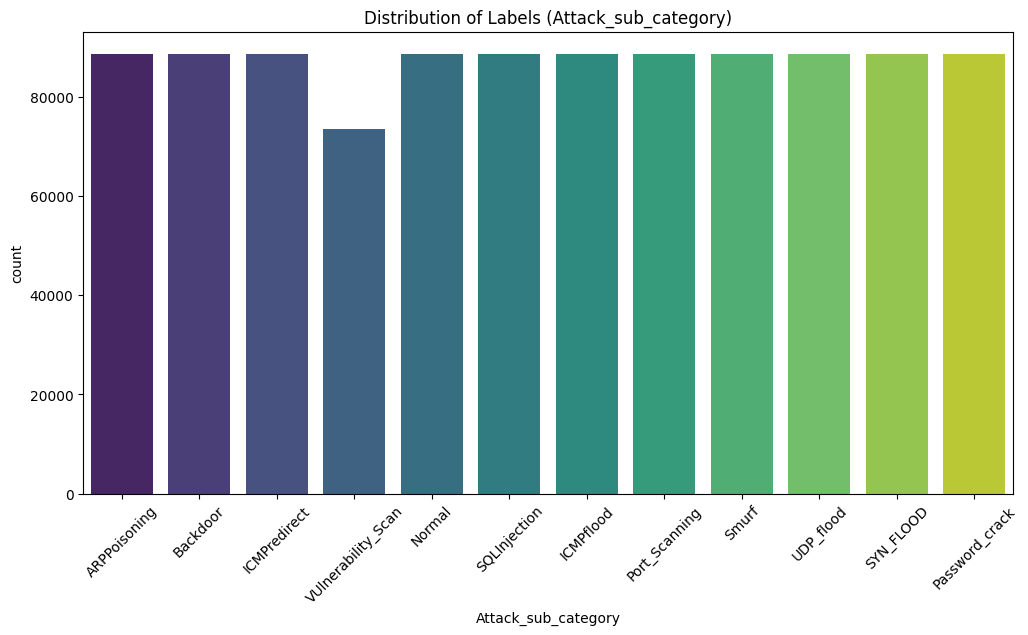

In [ ]:
target_col = df.columns[-1]

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x=target_col, hue=target_col, palette='viridis', legend=False)
plt.title(f'Distribution of Labels ({target_col})')
plt.xticks(rotation=45)
plt.show()

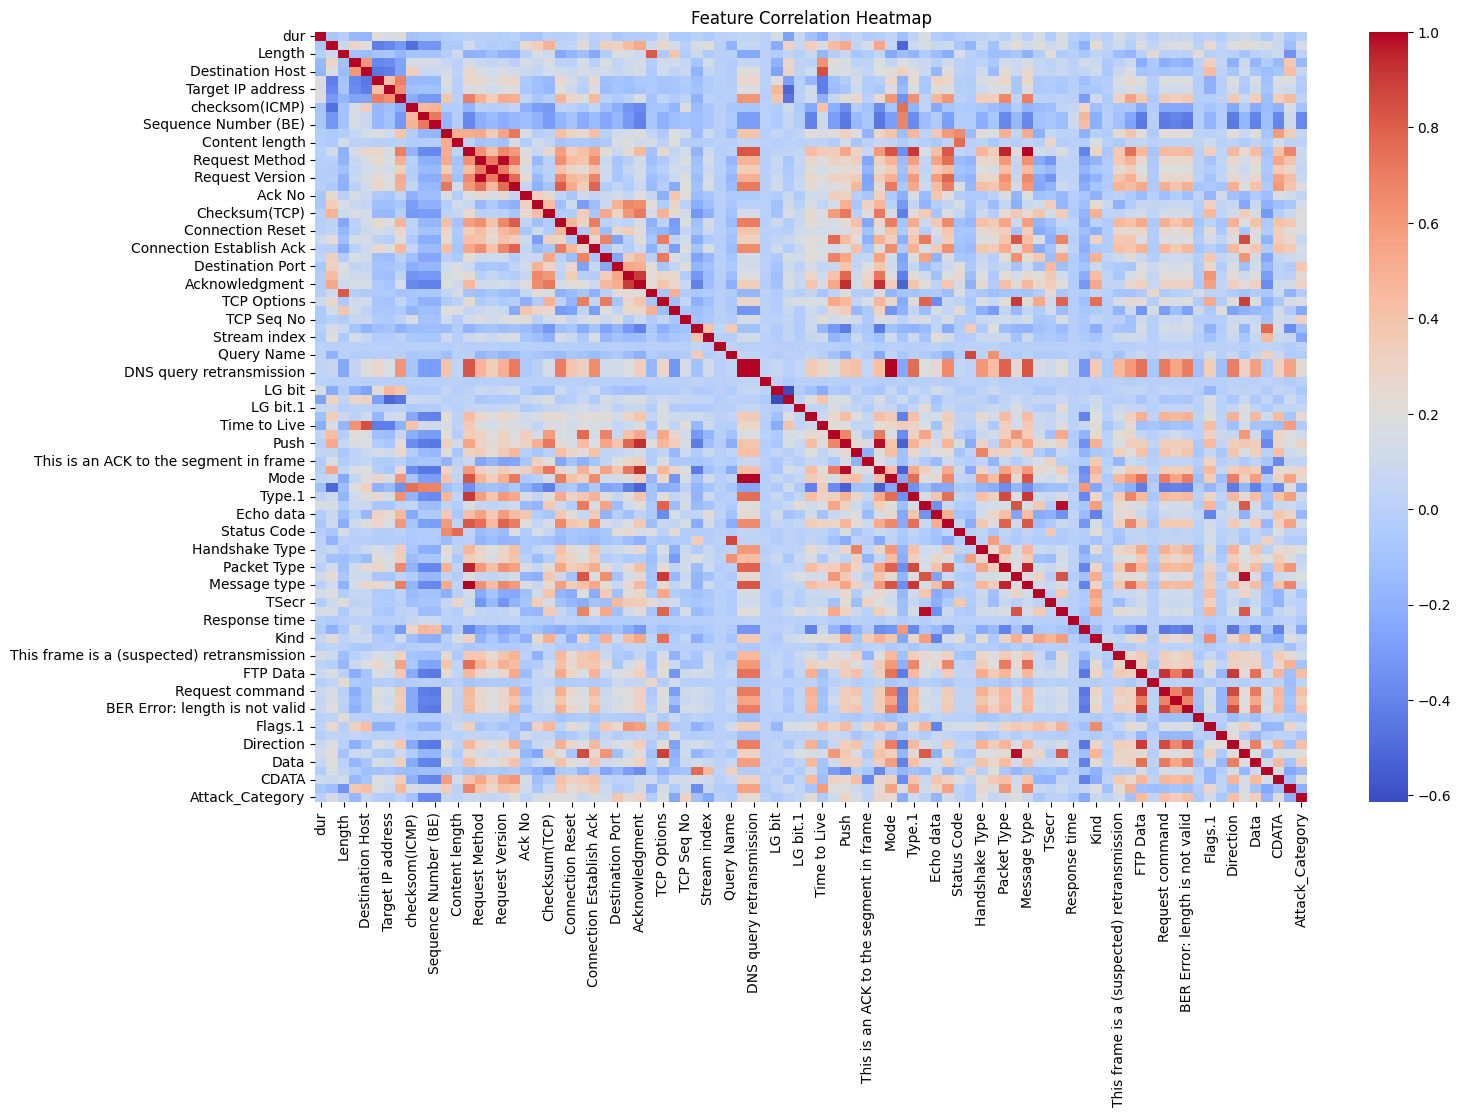

In [ ]:
plt.figure(figsize=(16, 10))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding
le = LabelEncoder()
df['Attack_sub_category_encoded'] = le.fit_transform(df['Attack_sub_category'])

# 2. Pemisahan Fitur & Target
# Kita menghapus kolom target asli dan kolom terkait lainnya untuk mencegah data leakage
X = df.drop(columns=['Attack_sub_category', 'Attack_sub_category_encoded', 'Label', 'Attack_Category'])
y = df['Attack_sub_category_encoded']

# 3. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print("\nMapping Label Encoding:")
for index, label in enumerate(le.classes_):
    print(f"{index}: {label}")

Ukuran X_train: (838860, 85)
Ukuran X_test: (209715, 85)

Mapping Label Encoding:
0: ARPPoisoning
1: Backdoor
2: ICMPflood
3: ICMPredirect
4: Normal
5: Password_crack
6: Port_Scanning
7: SQLInjection
8: SYN_FLOOD
9: Smurf
10: UDP_flood
11: VUlnerability_Scan


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif, RFE, SelectFromModel
from sklearn.preprocessing import StandardScaler

# Parameter umum untuk model
rf_params = {'random_state': 42, 'n_jobs': -1}

# A. Pipeline 1: Filter Method (SelectKBest)
pipeline_filter = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectKBest(score_func=f_classif, k=10)),
    ('model', RandomForestClassifier(**rf_params))
])

# B. Pipeline 2: Wrapper Method (RFE)
# Catatan: RFE bisa sangat lambat pada dataset besar dengan banyak fitur
pipeline_wrapper = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', RFE(estimator=RandomForestClassifier(**rf_params), n_features_to_select=10)),
    ('model', RandomForestClassifier(**rf_params))
])

# C. Pipeline 3: Embedded Method (SelectFromModel)
pipeline_embedded = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', SelectFromModel(RandomForestClassifier(**rf_params), max_features=10)),
    ('model', RandomForestClassifier(**rf_params))
])

print("Tiga Pipeline berhasil dibuat:")
print("1. pipeline_filter (SelectKBest)")
print("2. pipeline_wrapper (RFE)")
print("3. pipeline_embedded (SelectFromModel)")

Tiga Pipeline berhasil dibuat:
1. pipeline_filter (SelectKBest)
2. pipeline_wrapper (RFE)
3. pipeline_embedded (SelectFromModel)


In [ ]:
from sklearn.model_selection import cross_validate, StratifiedKFold
import time

# Optimasi: Menggunakan sampel 10% data untuk mempercepat evaluasi RFE/Embedded
# Stratified sampling memastikan distribusi kelas tetap sama
_X_sample, _, _y_sample, _ = train_test_split(X_train, y_train, train_size=0.1, stratify=y_train, random_state=42)

# Optimasi: Mengurangi n_splits menjadi 3 untuk kecepatan
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

results = {}

# Daftar pipeline yang akan dievaluasi
pipelines = {
    'Filter': pipeline_filter,
    'Embedded': pipeline_embedded,
    'Wrapper': pipeline_wrapper
}

for name, pipe in pipelines.items():
    print(f"Memulai evaluasi Pipeline {name} pada 10% sampel data...")
    start = time.time()
    # n_jobs=-1 menggunakan semua core yang tersedia
    results[name] = cross_validate(pipe, _X_sample, _y_sample, cv=skf, scoring=scoring_metrics, n_jobs=-1)
    print(f"Selesai dalam {time.time()-start:.2f} detik.\n")

Memulai evaluasi Pipeline Filter pada 10% sampel data...
Selesai dalam 8.78 detik.

Memulai evaluasi Pipeline Embedded pada 10% sampel data...
Selesai dalam 25.47 detik.

Memulai evaluasi Pipeline Wrapper pada 10% sampel data...
Selesai dalam 1005.83 detik.



,Method,Accuracy,Precision,Recall,F1-Score
2,Wrapper,0.995661,0.995564,0.995170,0.995335
1,Embedded,0.992979,0.993030,0.992945,0.992500
0,Filter,0.717498,0.807639,0.716548,0.692052


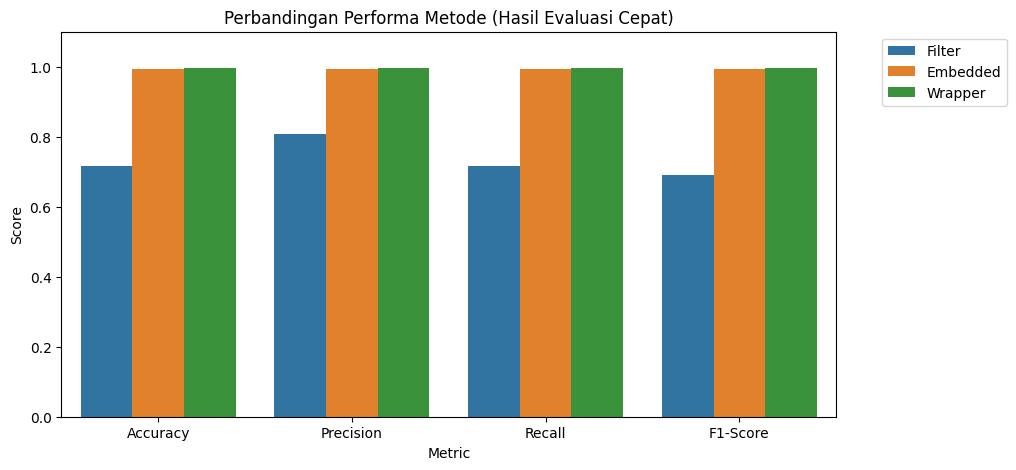

In [ ]:
# Merangkum hasil mean dari evaluasi cepat
comparison_data = []
for method, res in results.items():
    comparison_data.append({
        'Method': method,
        'Accuracy': np.mean(res['test_accuracy']),
        'Precision': np.mean(res['test_precision_macro']),
        'Recall': np.mean(res['test_recall_macro']),
        'F1-Score': np.mean(res['test_f1_macro'])
    })

df_results = pd.DataFrame(comparison_data)
display(df_results.sort_values(by='F1-Score', ascending=False))

# Visualisasi
df_melted = df_results.melt(id_vars='Method', var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 5))
sns.barplot(data=df_melted, x='Metric', y='Score', hue='Method')
plt.title('Perbandingan Performa Metode (Hasil Evaluasi Cepat)')
plt.ylim(0, 1.1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
from sklearn.feature_selection import RFE

# 1. Gunakan sampel yang lebih kecil (5%) untuk tuning yang sangat cepat
_X_fast_sample, _, _y_fast_sample, _ = train_test_split(
    X_train, y_train, train_size=0.05, stratify=y_train, random_state=42
)

# 2. Re-inisialisasi Pipeline
rf_params = {'random_state': 42, 'n_jobs': -1}
pipeline_tuning = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', RFE(estimator=RandomForestClassifier(**rf_params))),
    ('model', RandomForestClassifier(**rf_params))
])

# 3. Parameter Grid yang lebih ramping
param_grid = {
    'feature_selection__n_features_to_select': [10, 15], # Fokus pada jumlah fitur terbaik
    'model__n_estimators': [50],
    'model__max_depth': [15, None]
}

# 4. Jalankan GridSearchCV dengan cv=2 untuk kecepatan ekstra
grid_search = GridSearchCV(
    pipeline_tuning,
    param_grid,
    cv=2,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print(f"Memulai Hyperparameter Tuning Cepat pada {len(_X_fast_sample)} baris data...")
grid_search.fit(_X_fast_sample, _y_fast_sample)

print("\n--- Hasil Tuning Selesai ---")
print(f"Best Params: {grid_search.best_params_}")
print(f"Best F1-Score: {grid_search.best_score_:.4f}")

Memulai Hyperparameter Tuning Cepat pada 41943 baris data...
Fitting 2 folds for each of 4 candidates, totalling 8 fits

--- Hasil Tuning Selesai ---
Best Params: {'feature_selection__n_features_to_select': 15, 'model__max_depth': None, 'model__n_estimators': 50}
Best F1-Score: 0.9979


--- Laporan Klasifikasi Akhir (Test Set) ---
                    precision    recall  f1-score   support

      ARPPoisoning       1.00      1.00      1.00     17730
          Backdoor       1.00      1.00      1.00     17730
         ICMPflood       1.00      1.00      1.00     17730
      ICMPredirect       1.00      1.00      1.00     17730
            Normal       1.00      1.00      1.00     17730
    Password_crack       1.00      1.00      1.00     17730
     Port_Scanning       1.00      1.00      1.00     17730
      SQLInjection       0.99      0.99      0.99     17730
         SYN_FLOOD       1.00      1.00      1.00     17730
             Smurf       1.00      1.00      1.00     17730
         UDP_flood       1.00      1.00      1.00     17730
VUlnerability_Scan       0.99      0.99      0.99     14685

          accuracy                           1.00    209715
         macro avg       1.00      1.00      1.00    209715
      weighted avg       1.00      1.00      1.00    

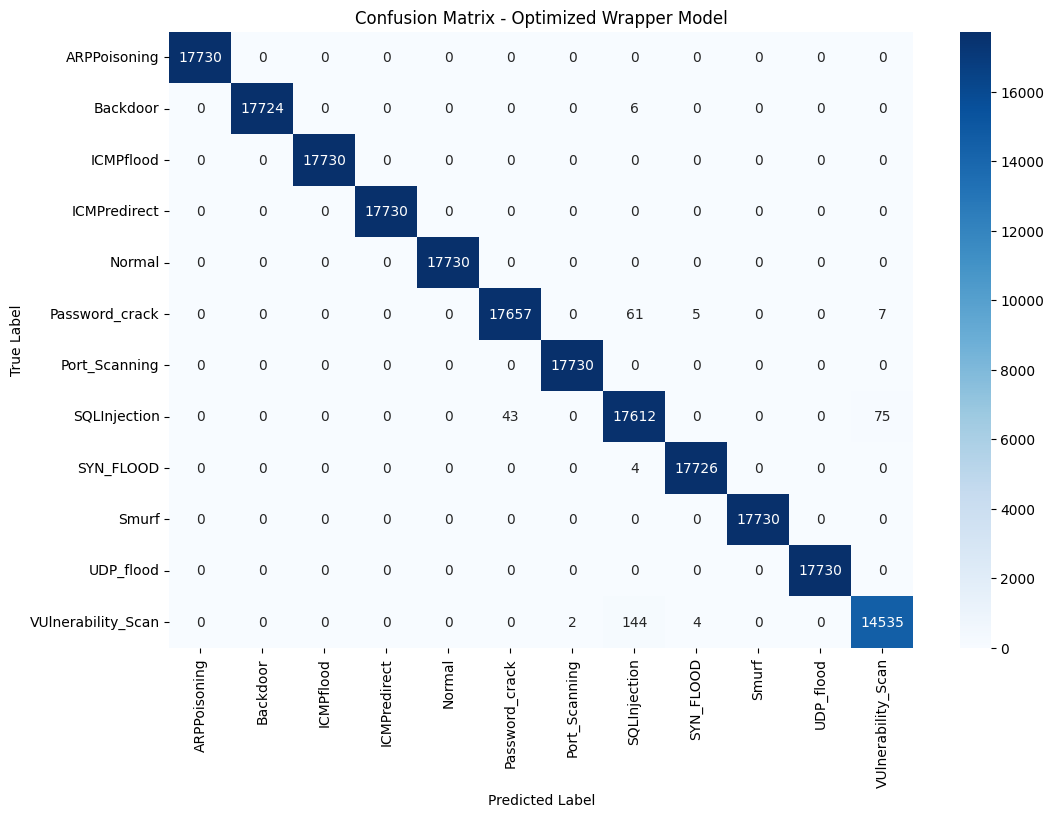


Model terbaik berhasil disimpan sebagai: pipeline_terbaik.pkl


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# 1. Gunakan model terbaik dari tuning untuk prediksi pada X_test
final_model = grid_search.best_estimator_
y_pred = final_model.predict(X_test)

# 2. Tampilkan Laporan Klasifikasi
print("--- Laporan Klasifikasi Akhir (Test Set) ---")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 3. Visualisasi Confusion Matrix
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Optimized Wrapper Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# 4. Simpan Model Pipeline Terbaik
model_filename = 'pipeline_terbaik.pkl'
joblib.dump(final_model, model_filename)
print(f"\nModel terbaik berhasil disimpan sebagai: {model_filename}")